# Function 1 - Non-Linear Logistic Regression

This notebook:
1. Loads Function 1 data (initial + weeks 1-5)
2. Visualizes the data
3. Applies Non-Linear Logistic Regression
4. Suggests the next point closest to the decision boundary

## Step 0: Import Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import mean_squared_error, log_loss

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_2d_scatter_with_distribution
)

import scripts.logistic_regression.nonlinear_logistic_regression as nonlinear_logistic_regression
importlib.reload(nonlinear_logistic_regression)
from scripts.logistic_regression import NonLinearLogisticRegression, make_binary_labels

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load Data for Function 1

In [3]:
# Load all data
base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")

Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


## Step 2: Prepare Function 1 Data

In [4]:
function_name = 'function_1'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week data
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']

# Combine all data
X_all = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1)
])

y_raw = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output]),
    np.array([week5_output])
])

print("="*60)
print(f"FUNCTION 1 - COMBINED DATA")
print("="*60)
print(f"Combined inputs shape: {X_all.shape}")
print(f"Combined outputs shape: {y_raw.shape}")
print(f"\nInput range: [{X_all.min():.3f}, {X_all.max():.3f}]")
print(f"Output range: [{y_raw.min():.6e}, {y_raw.max():.6e}]")
print("="*60)

FUNCTION 1 - COMBINED DATA
Combined inputs shape: (15, 2)
Combined outputs shape: (15,)

Input range: [0.000, 0.884]
Output range: [-3.606063e-03, 2.555929e-02]


## Step 3: Visualize the Data

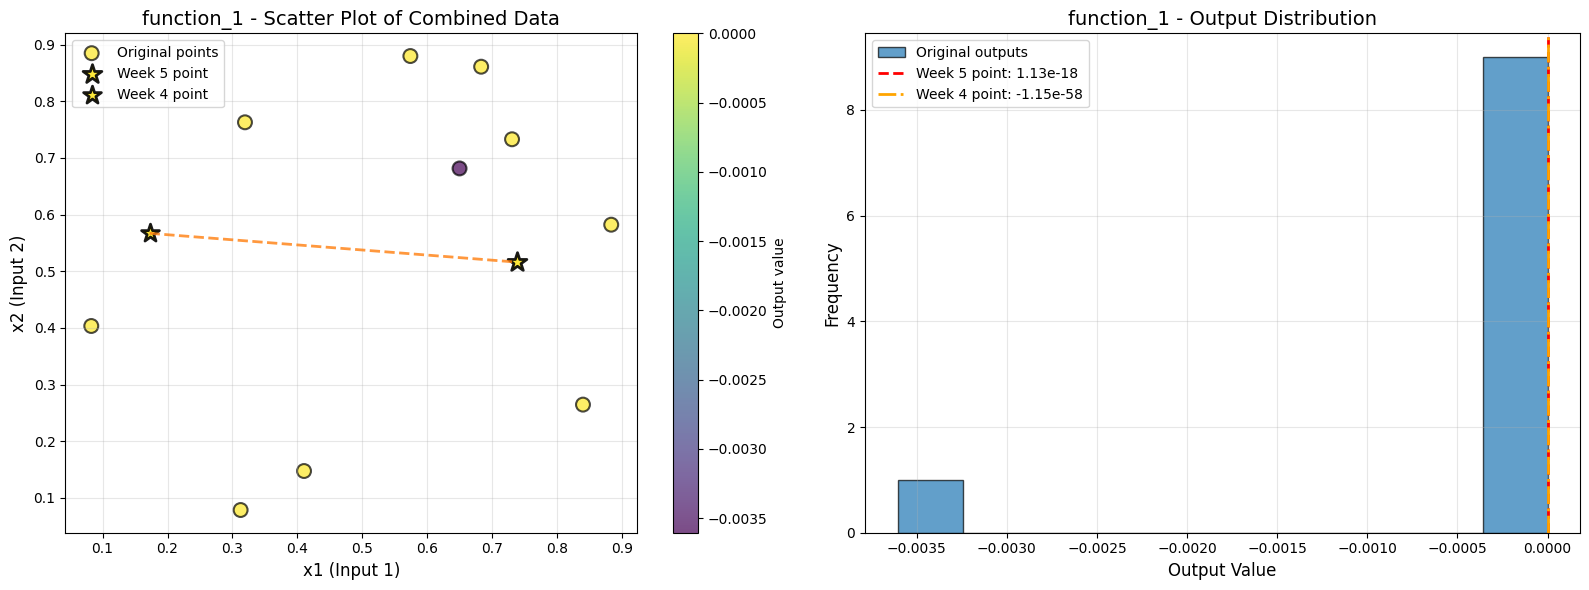

In [5]:
# Visualize with all weeks
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    week5_input, week5_output, 
    function_name,
    prior_input=week4_input,
    prior_output=week4_output,
    prior_point_label="Week 4 point",
    new_point_label="Week 5 point",
    connect_points=True,
    connect_color="tab:orange"
)

## Step 4: Hyperparameter Tuning for Non-Linear Logistic Regression

We'll tune:
- `degree`: Polynomial degree (1, 2, 3) - controls non-linearity
- `threshold_percentile`: For creating binary labels (50, 60, 70, 75, 80, 90)
- `penalty`: Regularization type ('l2')
- `C`: Inverse regularization strength (0.01, 0.1, 1.0, 10.0, 100.0)
- `max_iter`: Maximum iterations (1000, 2000, 5000)

We'll use Mean Squared Error (MSE) on the predicted probabilities vs. binary targets.

In [6]:
# Define hyperparameter grid
degrees = [1, 2, 3]  # 1 = linear (for comparison), 2 = quadratic, 3 = cubic
threshold_percentiles = [50, 60, 70, 75, 80, 90]
penalties = ['l2']  # Always use regularization for non-linear models
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
max_iters = [1000, 2000, 5000]

# Store results
results = []

print("Starting hyperparameter tuning for NON-LINEAR logistic regression...")
total_combos = len(degrees) * len(threshold_percentiles) * len(penalties) * len(C_values) * len(max_iters)
print(f"Total combinations: {total_combos}")
print("="*80)

for degree in degrees:
    for threshold_percentile in threshold_percentiles:
        # Create binary labels
        Y, threshold_used = make_binary_labels(y_raw, threshold_percentile=threshold_percentile)
        
        # Check if we have both classes
        if np.unique(Y).size < 2:
            print(f"Skipping threshold_percentile={threshold_percentile} (produces single class)")
            continue
        
        class_balance = f"{(Y == 0).sum()}/{(Y == 1).sum()}"
        
        for penalty in penalties:
            for max_iter in max_iters:
                for C in C_values:
                    try:
                        # Create and train non-linear model
                        nl_log_reg = NonLinearLogisticRegression(
                            degree=degree,
                            penalty=penalty,
                            C=C,
                            random_state=RANDOM_STATE,
                            max_iter=max_iter,
                            solver='lbfgs'
                        )
                        
                        # Fit and predict
                        nl_log_reg.fit(X_all, Y)
                        Y_pred = nl_log_reg.predict(X_all)
                        Y_pred_proba = nl_log_reg.predict_proba(X_all)[:, 1]
                        
                        # Calculate metrics
                        accuracy = nl_log_reg.accuracy(Y, Y_pred)
                        mse = mean_squared_error(Y, Y_pred_proba)
                        logloss = log_loss(Y, Y_pred_proba)
                        
                        # Store result
                        results.append({
                            'degree': degree,
                            'threshold_percentile': threshold_percentile,
                            'threshold_value': threshold_used,
                            'class_balance': class_balance,
                            'penalty': penalty,
                            'C': C,
                            'max_iter': max_iter,
                            'accuracy': accuracy,
                            'mse': mse,
                            'log_loss': logloss
                        })
                        
                    except Exception as e:
                        print(f"Error with params (degree={degree}, threshold={threshold_percentile}, penalty={penalty}, C={C}, max_iter={max_iter}): {str(e)}")
                        continue

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print(f"Completed! Tested {len(results_df)} configurations")
print("="*80)

Starting hyperparameter tuning for NON-LINEAR logistic regression...
Total combinations: 270

Completed! Tested 270 configurations


## Step 5: Analyze Results

In [7]:
# Sort by MSE (lower is better)
results_sorted = results_df.sort_values('mse')

print("\n" + "="*80)
print("TOP 10 MODELS BY MSE")
print("="*80)
print(results_sorted.head(10).to_string(index=False))

print("\n" + "="*80)
print("TOP 10 MODELS BY ACCURACY")
print("="*80)
results_by_acc = results_df.sort_values('accuracy', ascending=False)
print(results_by_acc.head(10).to_string(index=False))

print("\n" + "="*80)
print("TOP 10 MODELS BY LOG LOSS")
print("="*80)
results_by_loss = results_df.sort_values('log_loss')
print(results_by_loss.head(10).to_string(index=False))

# Compare by degree
print("\n" + "="*80)
print("COMPARISON BY POLYNOMIAL DEGREE")
print("="*80)
degree_comparison = results_df.groupby('degree').agg({
    'mse': ['mean', 'min', 'std'],
    'accuracy': ['mean', 'max', 'std'],
    'log_loss': ['mean', 'min', 'std']
}).round(6)
print(degree_comparison)


TOP 10 MODELS BY MSE
 degree  threshold_percentile  threshold_value class_balance penalty     C  max_iter  accuracy      mse  log_loss
      3                    90     1.605173e-09          13/2      l2 100.0      5000       1.0 0.002360  0.024221
      3                    90     1.605173e-09          13/2      l2 100.0      2000       1.0 0.002360  0.024221
      3                    90     1.605173e-09          13/2      l2 100.0      1000       1.0 0.002360  0.024221
      2                    90     1.605173e-09          13/2      l2 100.0      1000       1.0 0.002941  0.026761
      2                    90     1.605173e-09          13/2      l2 100.0      2000       1.0 0.002941  0.026761
      2                    90     1.605173e-09          13/2      l2 100.0      5000       1.0 0.002941  0.026761
      3                    90     1.605173e-09          13/2      l2  10.0      5000       1.0 0.019399  0.092956
      3                    90     1.605173e-09          13/2      

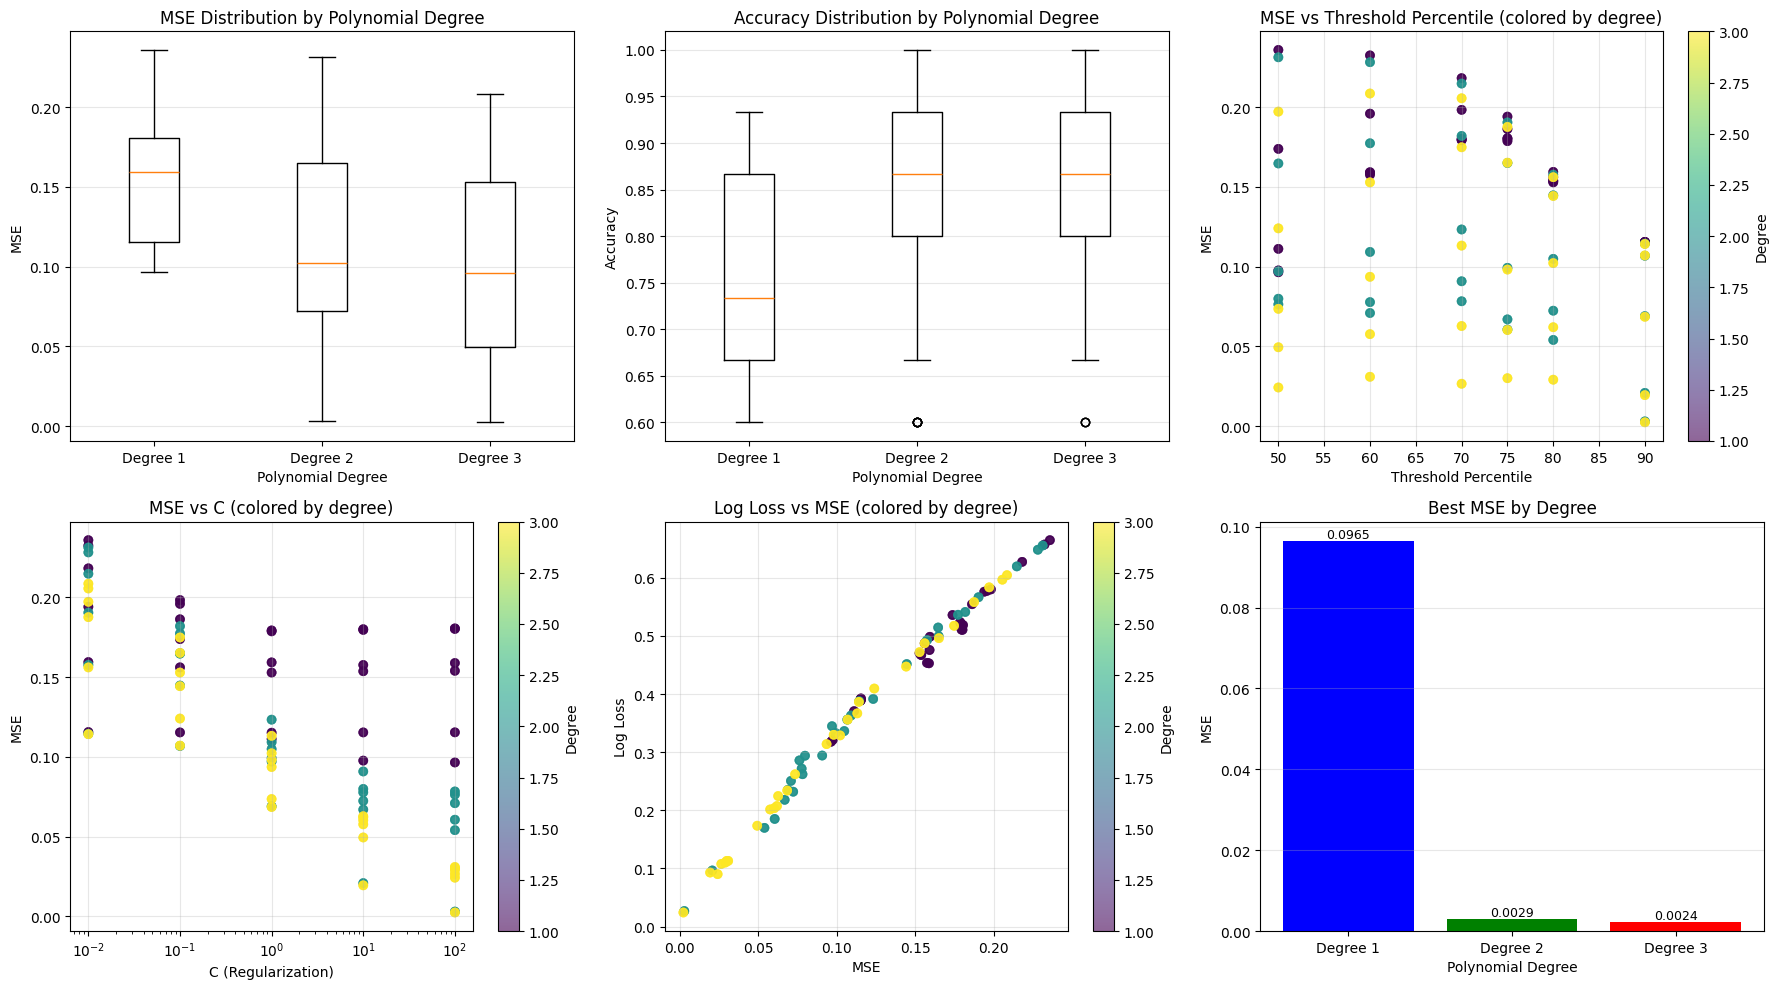

In [8]:
# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# MSE vs degree
degree_groups = results_df.groupby('degree')['mse'].apply(list)
axes[0, 0].boxplot([degree_groups[d] for d in sorted(degree_groups.index)], 
                    tick_labels=[f'Degree {d}' for d in sorted(degree_groups.index)])
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_xlabel('Polynomial Degree')
axes[0, 0].set_title('MSE Distribution by Polynomial Degree')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Accuracy vs degree
degree_acc = results_df.groupby('degree')['accuracy'].apply(list)
axes[0, 1].boxplot([degree_acc[d] for d in sorted(degree_acc.index)], 
                   tick_labels=[f'Degree {d}' for d in sorted(degree_acc.index)])
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_xlabel('Polynomial Degree')
axes[0, 1].set_title('Accuracy Distribution by Polynomial Degree')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# MSE vs threshold percentile
axes[0, 2].scatter(results_df['threshold_percentile'], results_df['mse'], 
                   c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[0, 2].set_xlabel('Threshold Percentile')
axes[0, 2].set_ylabel('MSE')
axes[0, 2].set_title('MSE vs Threshold Percentile (colored by degree)')
axes[0, 2].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0, 2].collections[0], ax=axes[0, 2])
cbar.set_label('Degree')

# MSE vs C
axes[1, 0].scatter(results_df['C'], results_df['mse'], 
                  c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('C (Regularization)')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('MSE vs C (colored by degree)')
axes[1, 0].grid(True, alpha=0.3)
cbar2 = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar2.set_label('Degree')

# Log Loss vs MSE
axes[1, 1].scatter(results_df['mse'], results_df['log_loss'], 
                   c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[1, 1].set_xlabel('MSE')
axes[1, 1].set_ylabel('Log Loss')
axes[1, 1].set_title('Log Loss vs MSE (colored by degree)')
axes[1, 1].grid(True, alpha=0.3)
cbar3 = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar3.set_label('Degree')

# Best model by degree
best_by_degree = results_df.loc[results_df.groupby('degree')['mse'].idxmin()]
axes[1, 2].bar([f'Degree {d}' for d in best_by_degree['degree']], 
               best_by_degree['mse'], color=['blue', 'green', 'red'])
axes[1, 2].set_ylabel('MSE')
axes[1, 2].set_xlabel('Polynomial Degree')
axes[1, 2].set_title('Best MSE by Degree')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, (idx, row) in enumerate(best_by_degree.iterrows()):
    axes[1, 2].text(i, row['mse'], f"{row['mse']:.4f}", 
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Step 6: Train Best Model

In [9]:
# Get best parameters
best_params = results_sorted.iloc[0]

print("="*80)
print("BEST MODEL PARAMETERS (by MSE)")
print("="*80)
for key, value in best_params.items():
    print(f"{key:25s}: {value}")
print("="*80)

# Recreate best model
Y_best, threshold_best = make_binary_labels(
    y_raw, 
    threshold_percentile=int(best_params['threshold_percentile'])
)

best_nl_log_reg = NonLinearLogisticRegression(
    degree=int(best_params['degree']),
    penalty=best_params['penalty'],
    C=best_params['C'],
    random_state=RANDOM_STATE,
    max_iter=int(best_params['max_iter']),
    solver='lbfgs'
)

# Fit best model
best_nl_log_reg.fit(X_all, Y_best)

# Show polynomial features created
if best_params['degree'] > 1:
    feature_names = best_nl_log_reg.get_polynomial_feature_names(['x1', 'x2'])
    print(f"\nPolynomial features created (degree={int(best_params['degree'])}):")
    print(f"  Total features: {len(feature_names)}")
    print(f"  Features: {', '.join(feature_names[:10])}{'...' if len(feature_names) > 10 else ''}")

print("\n✓ Best non-linear model trained successfully!")

BEST MODEL PARAMETERS (by MSE)
degree                   : 3
threshold_percentile     : 90
threshold_value          : 1.6051731030795518e-09
class_balance            : 13/2
penalty                  : l2
C                        : 100.0
max_iter                 : 5000
accuracy                 : 1.0
mse                      : 0.0023602128441074376
log_loss                 : 0.02422113813209415

Polynomial features created (degree=3):
  Total features: 10
  Features: 1, x1, x2, x1^2, x1 x2, x2^2, x1^3, x1^2 x2, x1 x2^2, x2^3

✓ Best non-linear model trained successfully!


## Step 7: Predict Next Point Closest to Decision Boundary

We'll use three methods to find the point closest to the **curved** decision boundary (probability ≈ 0.5):
1. Grid search
2. Random search
3. Optimization

In [10]:
# Define input space bounds (assuming [0, 1] for both dimensions)
bounds = [[0.0, 1.0], [0.0, 1.0]]

print("="*80)
print("FINDING NEXT POINT CLOSEST TO CURVED DECISION BOUNDARY")
print("="*80)

# Method 1: Grid search
print("\n1. Grid Search Method:")
next_point_grid, uncertainty_grid, prob_grid = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds,
    method='grid_search',
    n_candidates=10000,
    random_state=RANDOM_STATE
)
print(f"   Next point: {next_point_grid}")
print(f"   Probability: {prob_grid:.6f}")
print(f"   Distance from boundary: {uncertainty_grid:.6f}")

# Method 2: Random search
print("\n2. Random Search Method:")
next_point_random, uncertainty_random, prob_random = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds,
    method='random',
    n_candidates=10000,
    random_state=RANDOM_STATE
)
print(f"   Next point: {next_point_random}")
print(f"   Probability: {prob_random:.6f}")
print(f"   Distance from boundary: {uncertainty_random:.6f}")

# Method 3: Optimization
print("\n3. Optimization Method (most accurate):")
next_point_opt, uncertainty_opt, prob_opt = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds,
    method='optimize',
    random_state=RANDOM_STATE
)
print(f"   Next point: {next_point_opt}")
print(f"   Probability: {prob_opt:.6f}")
print(f"   Distance from boundary: {uncertainty_opt:.6f}")

print("\n" + "="*80)
print(f"RECOMMENDED NEXT POINT (using optimization): {next_point_opt}")
print("="*80)

FINDING NEXT POINT CLOSEST TO CURVED DECISION BOUNDARY

1. Grid Search Method:
   Next point: [0.65656566 0.32323232]
   Probability: 0.499653
   Distance from boundary: 0.000347

2. Random Search Method:
   Next point: [0.26512326 0.49505595]
   Probability: 0.499309
   Distance from boundary: 0.000691

3. Optimization Method (most accurate):
   Next point: [0.41666625 0.70954028]
   Probability: 0.500000
   Distance from boundary: 0.000000

RECOMMENDED NEXT POINT (using optimization): [0.41666625 0.70954028]


## Step 7.5: View Class Assignments for All Points

In [11]:
# Display class assignments for all points
print("="*80)
print("CLASS ASSIGNMENTS FOR ALL TRAINING POINTS")
print("="*80)
print(f"\nThreshold used: {threshold_best:.6e}")
print(f"Class 0: Output < {threshold_best:.6e} (below threshold)")
print(f"Class 1: Output >= {threshold_best:.6e} (above threshold)")
print(f"\nClass balance: {(Y_best == 0).sum()} points in Class 0, {(Y_best == 1).sum()} points in Class 1")
print("\n" + "-"*80)

# Create a DataFrame for easy viewing
class_df = pd.DataFrame({
    'Point Index': range(len(X_all)),
    'x1': X_all[:, 0],
    'x2': X_all[:, 1],
    'Output Value': y_raw,
    'Class': Y_best,
    'Class Label': ['Class 1 (High)' if y == 1 else 'Class 0 (Low)' for y in Y_best]
})

print("\nAll Points:")
print(class_df.to_string(index=False))

# Separate by class
print("\n" + "="*80)
print("CLASS 0 POINTS (Low Output - Below Threshold):")
print("="*80)
class0_points = class_df[class_df['Class'] == 0]
print(class0_points[['Point Index', 'x1', 'x2', 'Output Value']].to_string(index=False))

print("\n" + "="*80)
print("CLASS 1 POINTS (High Output - Above Threshold):")
print("="*80)
class1_points = class_df[class_df['Class'] == 1]
print(class1_points[['Point Index', 'x1', 'x2', 'Output Value']].to_string(index=False))
print("="*80)

CLASS ASSIGNMENTS FOR ALL TRAINING POINTS

Threshold used: 1.605173e-09
Class 0: Output < 1.605173e-09 (below threshold)
Class 1: Output >= 1.605173e-09 (above threshold)

Class balance: 13 points in Class 0, 2 points in Class 1

--------------------------------------------------------------------------------

All Points:
 Point Index       x1       x2  Output Value  Class    Class Label
           0 0.319404 0.762959  1.322677e-79      0  Class 0 (Low)
           1 0.574329 0.879898  1.033078e-46      0  Class 0 (Low)
           2 0.731024 0.733000  7.710875e-16      0  Class 0 (Low)
           3 0.840353 0.264732 3.341771e-124      0  Class 0 (Low)
           4 0.650114 0.681526 -3.606063e-03      0  Class 0 (Low)
           5 0.410437 0.147554 -2.159249e-54      0  Class 0 (Low)
           6 0.312691 0.078723 -2.089093e-91      0  Class 0 (Low)
           7 0.683418 0.861057  2.535001e-40      0  Class 0 (Low)
           8 0.082507 0.403488  3.606771e-81      0  Class 0 (Low)
      

## Step 8: Visualize Curved Decision Boundary and Next Point

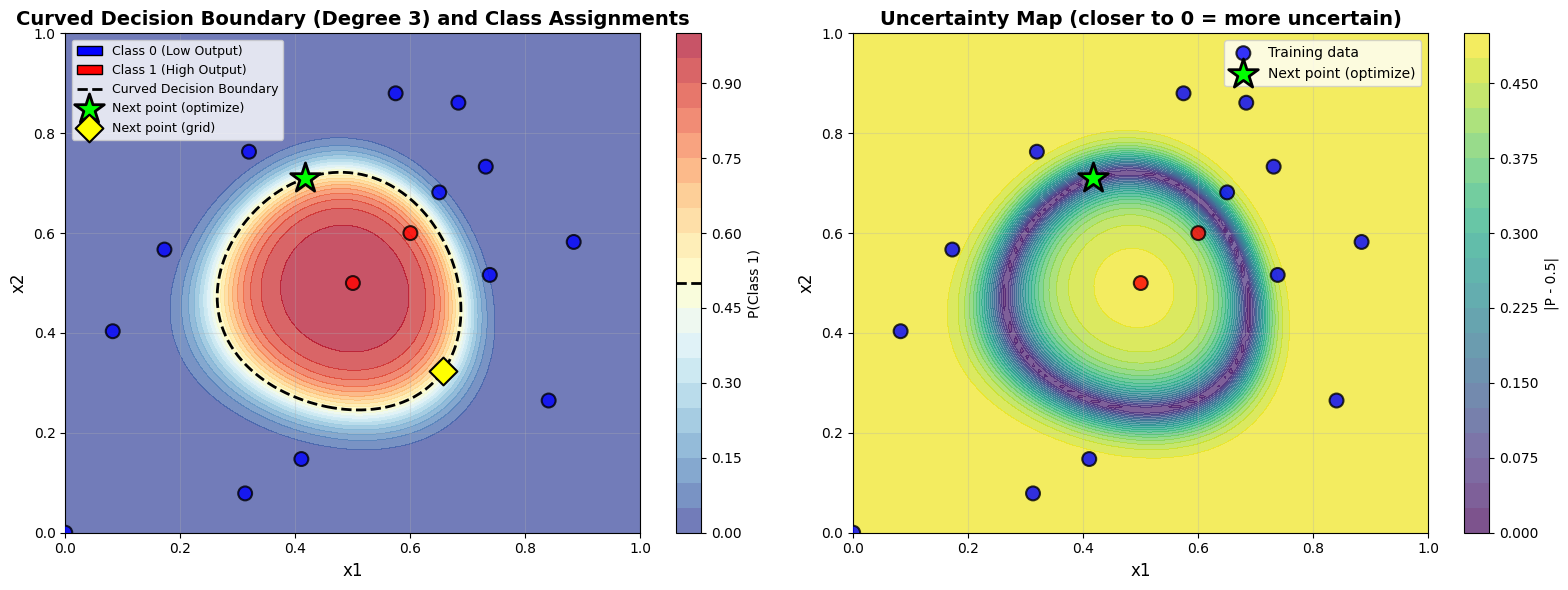

In [12]:
# Create a grid for visualization
n_grid = 100
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

# Get predictions for grid (non-linear model handles transformation internally)
probs_grid = best_nl_log_reg.predict_proba(grid_points)[:, 1].reshape(n_grid, n_grid)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Curved decision boundary with probability contours
ax = axes[0]
contour = ax.contourf(X1_grid, X2_grid, probs_grid, levels=20, cmap='RdYlBu_r', alpha=0.7)
ax.contour(X1_grid, X2_grid, probs_grid, levels=[0.5], colors='black', linewidths=2, 
           linestyles='--')

# Plot training points colored by class (blue=Class 0, red=Class 1)
colors_class = ['blue' if y == 0 else 'red' for y in Y_best]
scatter = ax.scatter(X_all[:, 0], X_all[:, 1], c=colors_class, 
                    s=100, edgecolors='black', linewidths=1.5, zorder=5, alpha=0.8)

# Add class labels to legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Class 0 (Low Output)'),
    Patch(facecolor='red', edgecolor='black', label='Class 1 (High Output)'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Curved Decision Boundary'),
]

# Plot suggested next points
star = ax.scatter(next_point_opt[0], next_point_opt[1], c='lime', marker='*', 
          s=500, edgecolors='black', linewidths=2, zorder=10, label='Next point (optimize)')
diamond = ax.scatter(next_point_grid[0], next_point_grid[1], c='yellow', marker='D', 
          s=200, edgecolors='black', linewidths=1.5, zorder=9, label='Next point (grid)')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title(f'Curved Decision Boundary (Degree {int(best_params["degree"])}) and Class Assignments', 
             fontsize=14, fontweight='bold')
ax.legend(handles=legend_elements + [star, diamond], loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax, label='P(Class 1)')
cbar.ax.axhline(0.5, color='black', linestyle='--', linewidth=2)

# Right plot: Uncertainty map
ax = axes[1]
uncertainties_grid = np.abs(probs_grid - 0.5)
contour2 = ax.contourf(X1_grid, X2_grid, uncertainties_grid, levels=20, cmap='viridis', alpha=0.7)

# Plot training points with class colors
ax.scatter(X_all[:, 0], X_all[:, 1], c=colors_class, s=100, edgecolors='black', 
          linewidths=1.5, zorder=5, alpha=0.8, label='Training data')

# Plot suggested next point
ax.scatter(next_point_opt[0], next_point_opt[1], c='lime', marker='*', 
          s=500, edgecolors='black', linewidths=2, zorder=10, label='Next point (optimize)')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Uncertainty Map (closer to 0 = more uncertain)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.colorbar(contour2, ax=ax, label='|P - 0.5|')

plt.tight_layout()
plt.show()

In [13]:
print("="*80)
print("SUMMARY - FUNCTION 1 NON-LINEAR LOGISTIC REGRESSION")
print("="*80)
print(f"\nData Summary:")
print(f"  - Total samples: {len(X_all)}")
print(f"  - Input dimensions: {X_all.shape[1]}")
print(f"  - Input space: [0, 1] x [0, 1]")
print(f"  - Output range: [{y_raw.min():.6e}, {y_raw.max():.6e}]")

print(f"\nBest Model:")
print(f"  - Polynomial degree: {best_params['degree']} ({'Linear' if best_params['degree'] == 1 else 'Quadratic' if best_params['degree'] == 2 else 'Cubic'})")
print(f"  - Threshold percentile: {best_params['threshold_percentile']}")
print(f"  - Threshold value: {best_params['threshold_value']:.6e}")
print(f"  - Class balance (0/1): {best_params['class_balance']}")
print(f"  - Penalty: {best_params['penalty']}")
print(f"  - C: {best_params['C']}")
print(f"  - Max iterations: {best_params['max_iter']}")
print(f"  - MSE: {best_params['mse']:.6f}")
print(f"  - Accuracy: {best_params['accuracy']:.4f}")
print(f"  - Log Loss: {best_params['log_loss']:.6f}")

print(f"\nRecommended Next Point:")
print(f"  - Coordinates: {next_point_opt}")
print(f"  - Predicted probability: {prob_opt:.6f}")
print(f"  - Distance from boundary: {uncertainty_opt:.6f}")

print(f"\nInterpretation:")
print(f"  This point is closest to the CURVED decision boundary (P ≈ 0.5), making it")
print(f"  the most uncertain point for the non-linear model. Evaluating this point will")
print(f"  provide maximum information to refine the decision boundary.")
if best_params['degree'] > 1:
    print(f"  The non-linear boundary (degree {int(best_params['degree'])}) can capture")
    print(f"  more complex patterns than a linear boundary.")
print("="*80)

SUMMARY - FUNCTION 1 NON-LINEAR LOGISTIC REGRESSION

Data Summary:
  - Total samples: 15
  - Input dimensions: 2
  - Input space: [0, 1] x [0, 1]
  - Output range: [-3.606063e-03, 2.555929e-02]

Best Model:
  - Polynomial degree: 3 (Cubic)
  - Threshold percentile: 90
  - Threshold value: 1.605173e-09
  - Class balance (0/1): 13/2
  - Penalty: l2
  - C: 100.0
  - Max iterations: 5000
  - MSE: 0.002360
  - Accuracy: 1.0000
  - Log Loss: 0.024221

Recommended Next Point:
  - Coordinates: [0.41666625 0.70954028]
  - Predicted probability: 0.500000
  - Distance from boundary: 0.000000

Interpretation:
  This point is closest to the CURVED decision boundary (P ≈ 0.5), making it
  the most uncertain point for the non-linear model. Evaluating this point will
  provide maximum information to refine the decision boundary.
  The non-linear boundary (degree 3) can capture
  more complex patterns than a linear boundary.


## Step 10: Save Next Point for Submission Format

In [14]:
# Save next point in format compatible with submission
import json
from pathlib import Path

# Save to JSON file in results/
Path('results').mkdir(exist_ok=True)
function1_next_point = {
    'function_name': 'function_1',
    'next_point': next_point_opt.tolist(),
    'formatted': '-'.join([f'{x:.6f}' for x in next_point_opt]),
    'method': 'nonlinear_logistic_regression',
    'degree': int(best_params['degree'])
}

with open('results/function1_next_point.json', 'w') as f:
    json.dump(function1_next_point, f, indent=2)

print("="*80)
print("FUNCTION 1 NEXT POINT - SUBMISSION FORMAT")
print("="*80)
print(f"\nNext point: {next_point_opt}")
print(f"Formatted for submission: {function1_next_point['formatted']}")
print(f"Method: Non-Linear Logistic Regression (degree={int(best_params['degree'])})")
print(f"\n✓ Saved to 'results/function1_next_point.json'")
print("="*80)

FUNCTION 1 NEXT POINT - SUBMISSION FORMAT

Next point: [0.41666625 0.70954028]
Formatted for submission: 0.416666-0.709540
Method: Non-Linear Logistic Regression (degree=3)

✓ Saved to 'results/function1_next_point.json'
